In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [53]:
print("Dataset Shape:", df.shape)

Dataset Shape: (8807, 12)


In [54]:
print("Columns in Dataset:")
print(df.columns.tolist())

Columns in Dataset:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [56]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [57]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [58]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


## 2. Data Cleaning and Preparation

Before creating visualizations, the dataset is checked for missing
values, duplicate records, and inconsistent data types. The required
columns are also converted into suitable formats for visualization.

In [59]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [60]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (8807, 12)


In [61]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

print(df["date_added"].dtype)

datetime64[ns]


In [62]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

,0
director,2634
country,831
cast,825
date_added,98
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 3. Key Performance Indicators (KPIs)

The following KPIs provide a high-level overview of the Netflix
content library. These metrics summarize the total number of
titles, content types, countries represented, and the overall
content timeline.

In [64]:
# Total number of titles
total_titles = df["title"].nunique()

# Number of movies
total_movies = (df["type"] == "Movie").sum()

# Number of TV shows
total_tv_shows = (df["type"] == "TV Show").sum()

# Number of countries
total_countries = df["country"].dropna().str.split(", ").explode().nunique()

# Earliest release year
earliest_year = df["release_year"].min()

# Latest release year
latest_year = df["release_year"].max()

print(f"Total Titles: {total_titles:,}")
print(f"Movies: {total_movies:,}")
print(f"TV Shows: {total_tv_shows:,}")
print(f"Countries Represented: {total_countries:,}")
print(f"Earliest Release Year: {earliest_year}")
print(f"Latest Release Year: {latest_year}")

Total Titles: 8,807
Movies: 6,131
TV Shows: 2,676
Countries Represented: 127
Earliest Release Year: 1925
Latest Release Year: 2021


In [65]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Titles",
        "Movies",
        "TV Shows",
        "Countries Represented",
        "Earliest Release Year",
        "Latest Release Year"
    ],
    "Value": [
        total_titles,
        total_movies,
        total_tv_shows,
        total_countries,
        earliest_year,
        latest_year
    ]
})

kpi_summary

,KPI,Value
0,Total Titles,8807
1,Movies,6131
2,TV Shows,2676
3,Countries Represented,127
4,Earliest Release Year,1925
5,Latest Release Year,2021


## 4. Movies vs TV Shows

This visualization compares the distribution of Movies and TV Shows
in the Netflix content library to determine which content type
represents the larger share of the catalog.

In [66]:
content_type = df["type"].value_counts()

content_type

,count
type,
Movie,6131
TV Show,2676


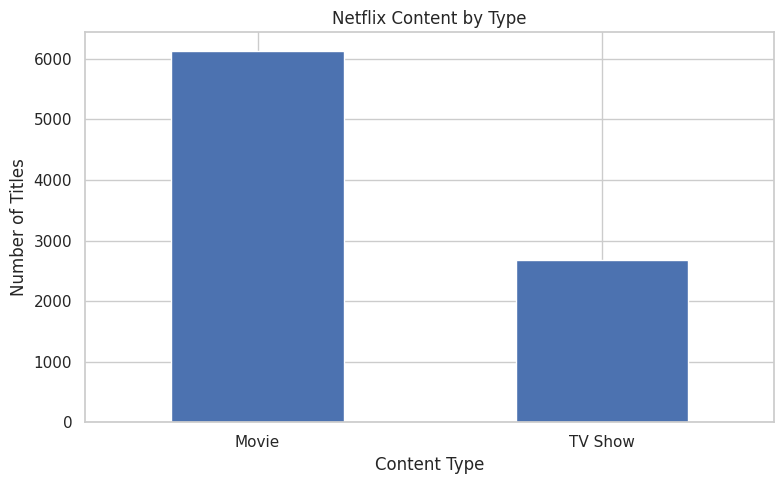

In [67]:
plt.figure(figsize=(8, 5))

content_type.plot(kind="bar")

plt.title("Netflix Content by Type")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [68]:
content_percentage = (
    df["type"].value_counts(normalize=True) * 100
).round(2)

content_percentage

,proportion
type,
Movie,69.62
TV Show,30.38


## 5. Content Distribution by Release Year

This visualization examines the distribution of Netflix titles
across release years to identify periods with higher concentrations
of content.

In [69]:
yearly_content = (
    df.groupby("release_year")["title"]
    .nunique()
)

yearly_content.tail(20)

,title
release_year,
2002,51
2003,61
2004,64
2005,80
2006,96
2007,88
2008,136
2009,152
2010,194


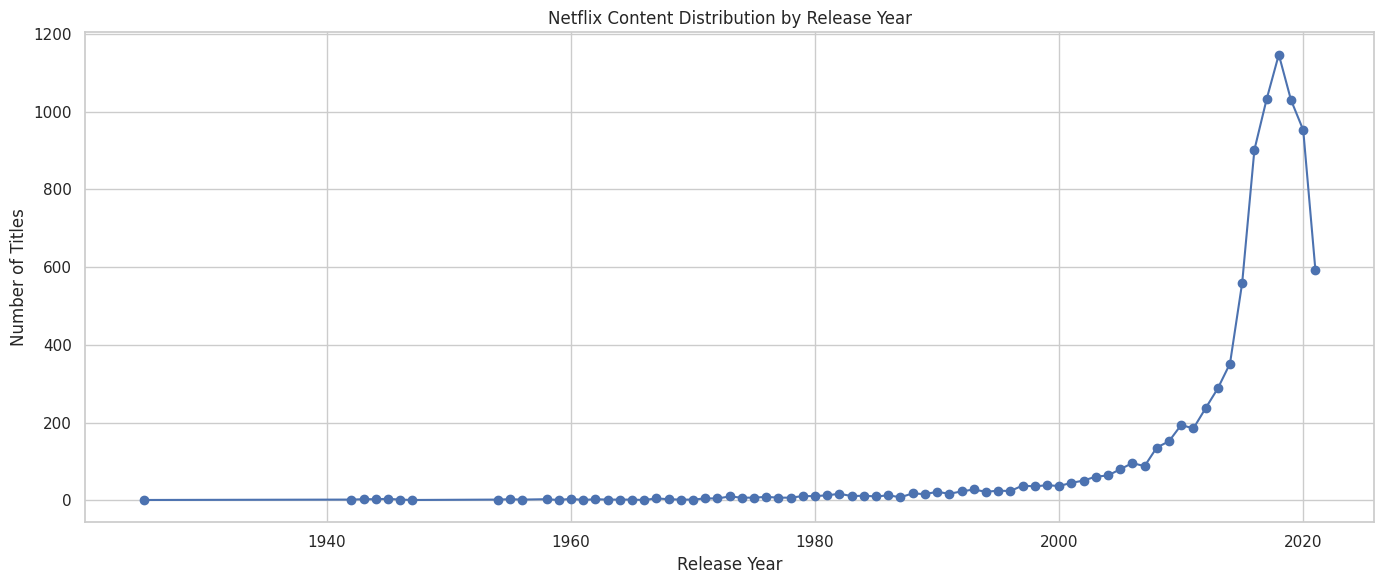

In [70]:
plt.figure(figsize=(14, 6))

plt.plot(
    yearly_content.index,
    yearly_content.values,
    marker="o"
)

plt.title("Netflix Content Distribution by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

## 6. Movies vs TV Shows Over Time

This visualization compares the number of Movies and TV Shows
across release years to examine how the composition of Netflix
content has changed over time.

In [71]:
type_by_year = (
    df.groupby(["release_year", "type"])
    .size()
    .unstack(fill_value=0)
)

type_by_year.tail()

type,Movie,TV Show
release_year,,
2017,767,265
2018,767,380
2019,633,397
2020,517,436
2021,277,315


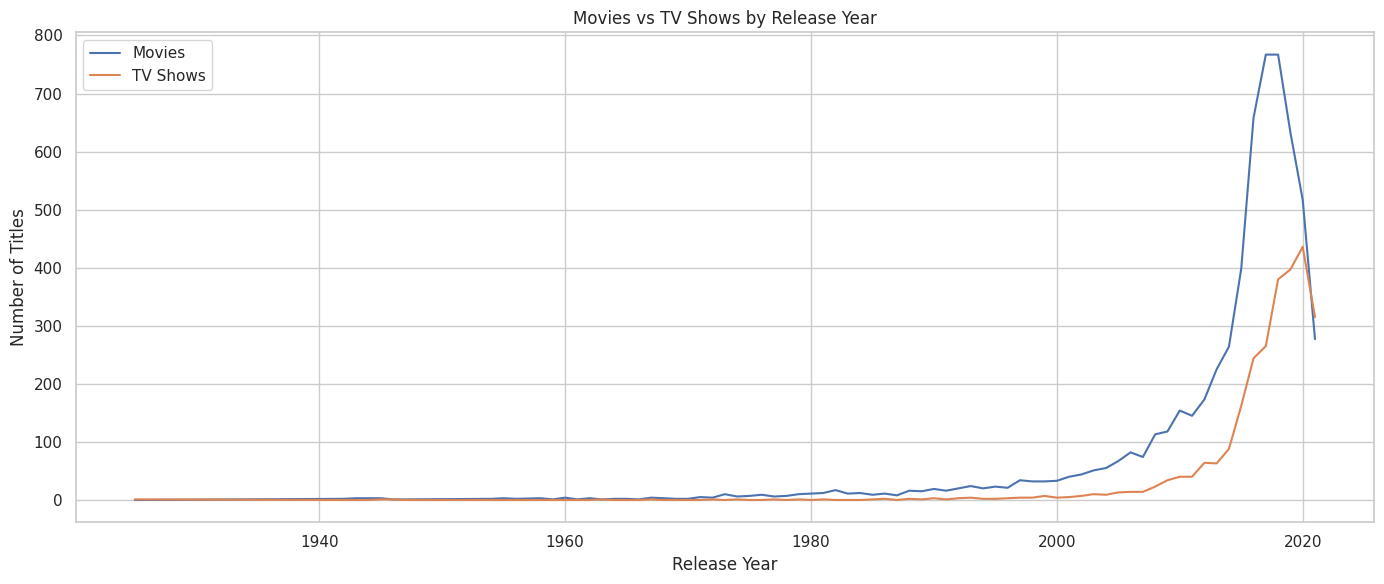

In [72]:
plt.figure(figsize=(14, 6))

plt.plot(
    type_by_year.index,
    type_by_year["Movie"],
    label="Movies"
)

plt.plot(
    type_by_year.index,
    type_by_year["TV Show"],
    label="TV Shows"
)

plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()

plt.tight_layout()
plt.show()

## 7. Top Countries by Number of Netflix Titles

This analysis identifies the countries that contribute the largest
number of titles to the Netflix content library.

In [73]:
country_data = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_countries = country_data.value_counts().head(10)

top_countries

,count
country,
United States,3689
India,1046
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


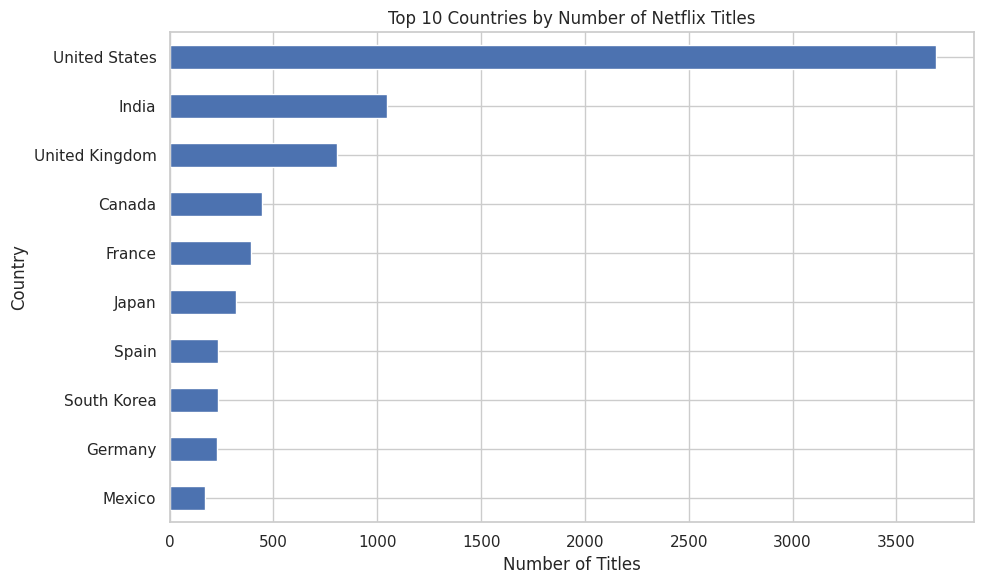

In [74]:
plt.figure(figsize=(10, 6))

top_countries.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

## 8. Genre Analysis

This section analyzes the distribution of genres in the Netflix
content library to identify the most common content categories.
Since a title can belong to multiple genres, the genre data is
split and analyzed individually.

In [75]:
genre_data = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
)

genre_counts = genre_data.value_counts()

genre_counts.head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


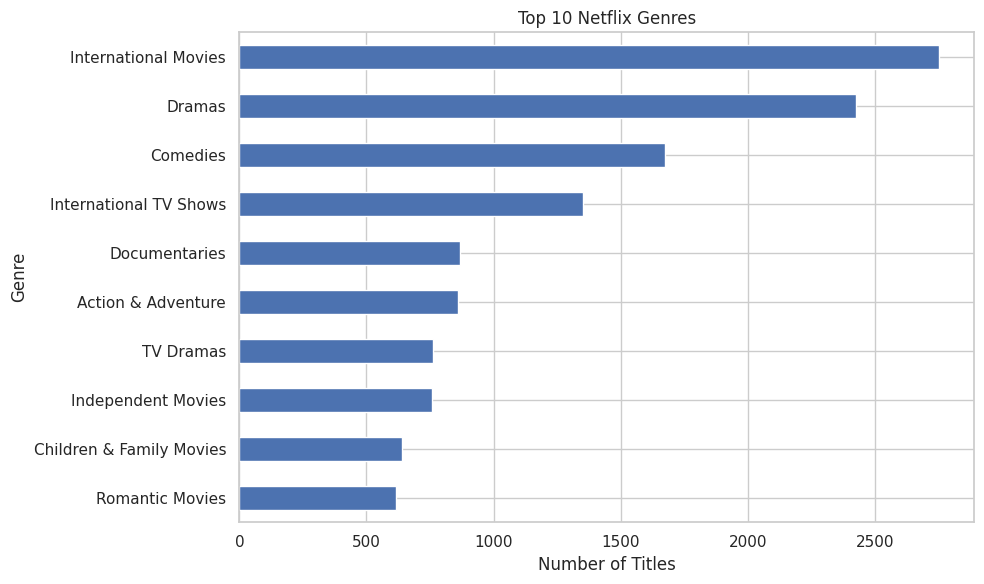

In [76]:
top_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))

top_genres.sort_values().plot(kind="barh")

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

In [77]:
genre_percentage = (
    genre_counts / len(df) * 100
).round(2)

genre_percentage.head(10)

,count
listed_in,
International Movies,31.25
Dramas,27.56
Comedies,19.01
International TV Shows,15.34
Documentaries,9.87
Action & Adventure,9.75
TV Dramas,8.66
Independent Movies,8.58
Children & Family Movies,7.28


## 9. Rating Analysis

This section examines the distribution of content ratings across
the Netflix catalog to understand which audience classifications
are most common.

In [78]:
rating_counts = df["rating"].value_counts()

rating_counts

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


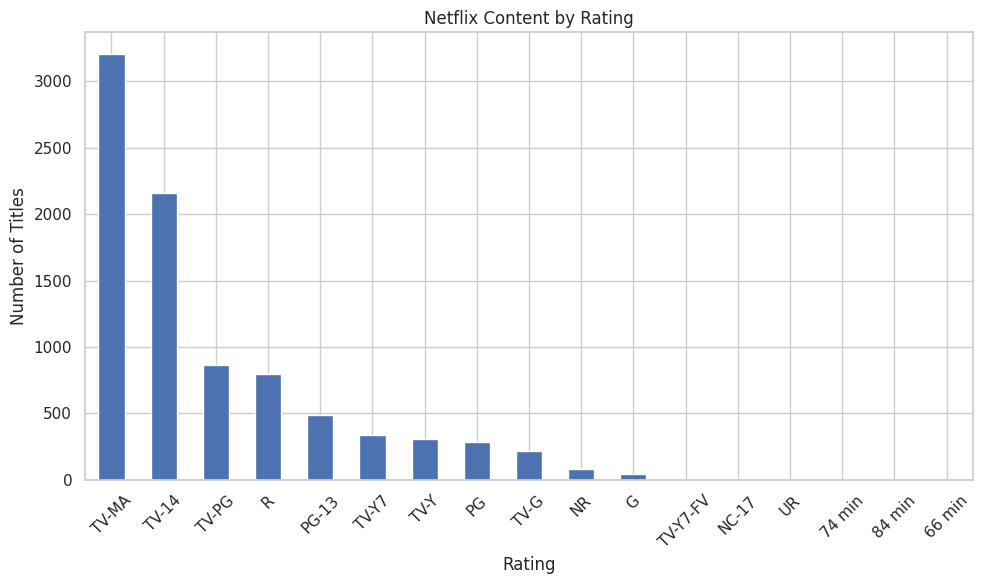

In [79]:
plt.figure(figsize=(10, 6))

rating_counts.plot(kind="bar")

plt.title("Netflix Content by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [80]:
rating_by_type = (
    df.groupby(["rating", "type"])
    .size()
    .unstack(fill_value=0)
)

rating_by_type

type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2


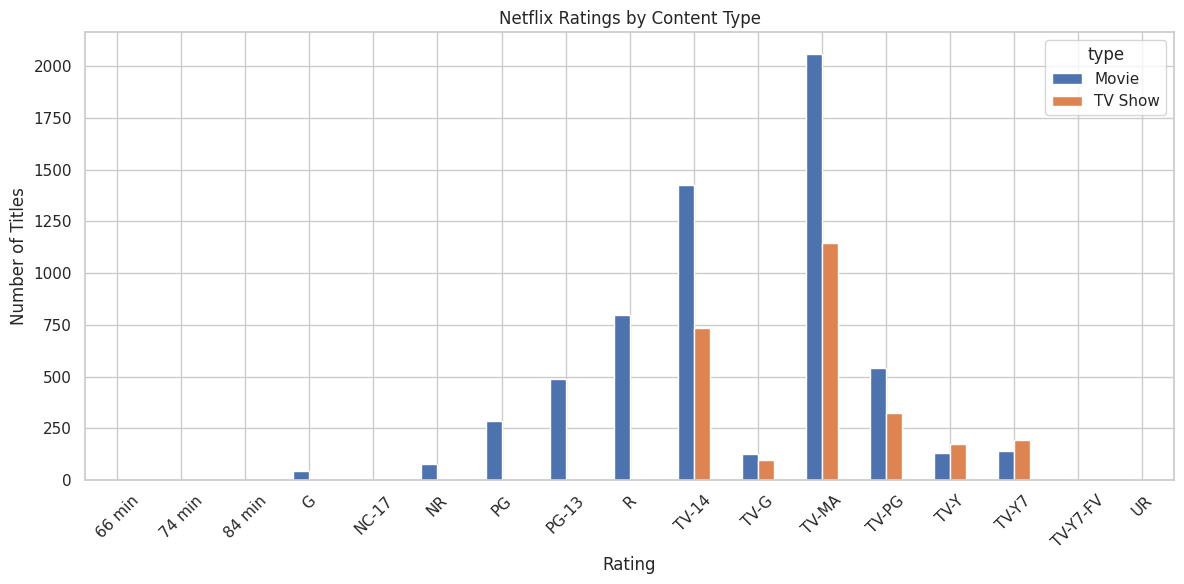

In [81]:
rating_by_type.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Netflix Ratings by Content Type")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [82]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

In [83]:
df["date_added"].isna().sum()

np.int64(98)

In [84]:
df["month_added"] = df["date_added"].dt.month

In [85]:
monthly_added = (
    df["month_added"]
    .value_counts()
    .sort_index()
)

monthly_added

,count
month_added,
1.0,727
2.0,557
3.0,734
4.0,759
5.0,626
6.0,724
7.0,819
8.0,749
9.0,765


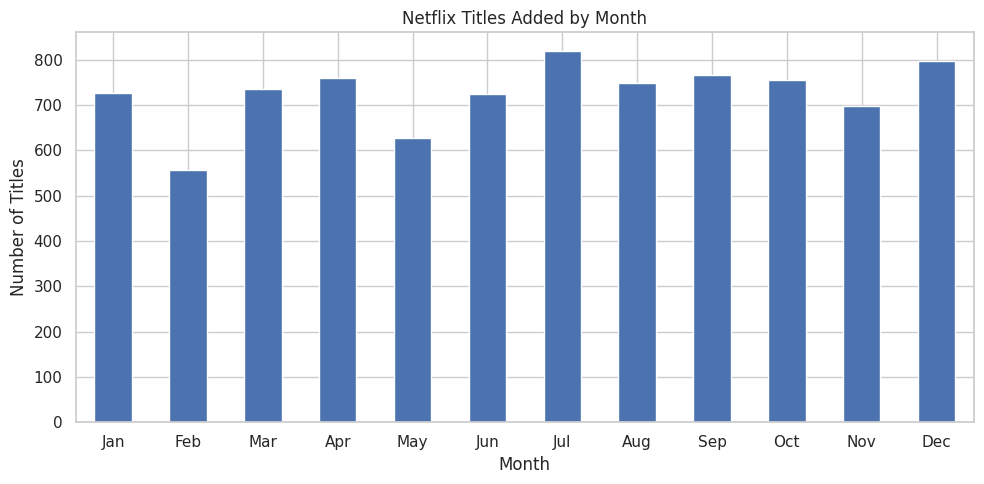

In [86]:
plt.figure(figsize=(10, 5))

monthly_added.plot(
    kind="bar"
)

plt.title("Netflix Titles Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.xticks(range(12), [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
], rotation=0)

plt.tight_layout()
plt.show()

In [87]:
# Check duration values
print("Sample duration values:")
display(df[['type', 'duration']].head(10))

print("\nUnique duration examples:")
print(df['duration'].dropna().unique()[:30])

Sample duration values:


,type,duration
0,Movie,90 min
1,TV Show,2 Seasons
2,TV Show,1 Season
3,TV Show,1 Season
4,TV Show,2 Seasons
5,TV Show,1 Season
6,Movie,91 min
7,Movie,125 min
8,TV Show,9 Seasons
9,Movie,104 min



Unique duration examples:
['90 min' '2 Seasons' '1 Season' '91 min' '125 min' '9 Seasons' '104 min'
 '127 min' '4 Seasons' '67 min' '94 min' '5 Seasons' '161 min' '61 min'
 '166 min' '147 min' '103 min' '97 min' '106 min' '111 min' '3 Seasons'
 '110 min' '105 min' '96 min' '124 min' '116 min' '98 min' '23 min'
 '115 min' '122 min']


In [88]:
# ==========================================
# STEP 13A: MOVIE DURATION ANALYSIS
# ==========================================

# Select only movies
movies = df[df['type'] == 'Movie'].copy()

# Extract numeric duration in minutes
movies['duration_minutes'] = (
    movies['duration']
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

# Remove missing duration values
movies_duration = movies.dropna(subset=['duration_minutes'])

# Display summary statistics
print("==============================================")
print("        MOVIE DURATION ANALYSIS")
print("==============================================")

print(f"Number of movies analyzed: {len(movies_duration)}")
print(f"Average movie duration: {movies_duration['duration_minutes'].mean():.2f} minutes")
print(f"Median movie duration: {movies_duration['duration_minutes'].median():.2f} minutes")
print(f"Shortest movie duration: {movies_duration['duration_minutes'].min():.0f} minutes")
print(f"Longest movie duration: {movies_duration['duration_minutes'].max():.0f} minutes")

        MOVIE DURATION ANALYSIS
Number of movies analyzed: 6128
Average movie duration: 99.58 minutes
Median movie duration: 98.00 minutes
Shortest movie duration: 3 minutes
Longest movie duration: 312 minutes


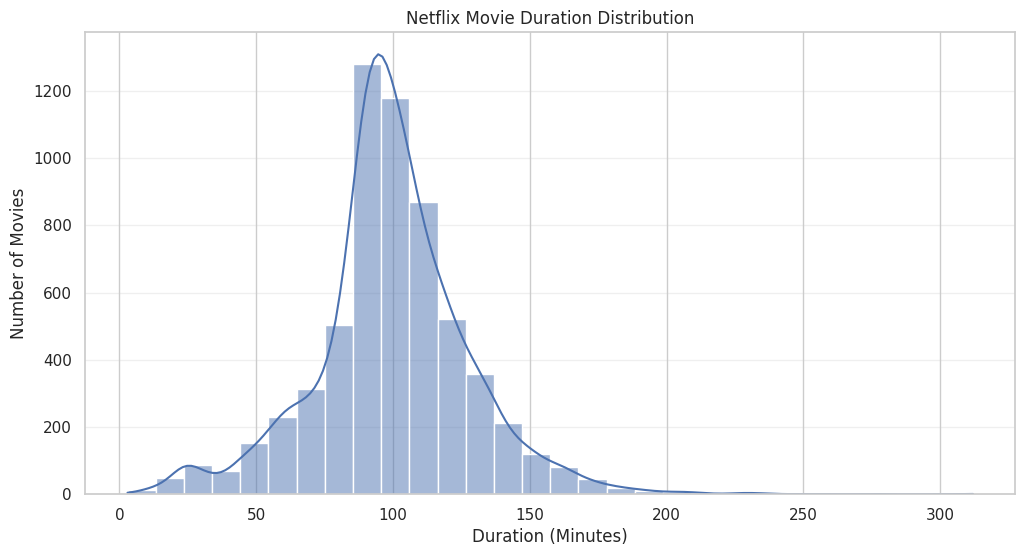

In [89]:
# ==========================================
# MOVIE DURATION DISTRIBUTION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.histplot(
    movies_duration['duration_minutes'],
    bins=30,
    kde=True
)

plt.title('Netflix Movie Duration Distribution')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [90]:
# ==========================================
# STEP 13C: TV SHOW SEASONS ANALYSIS
# ==========================================

# Select only TV Shows
tv_shows = df[df['type'] == 'TV Show'].copy()

# Extract number of seasons
tv_shows['seasons'] = (
    tv_shows['duration']
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

# Remove missing values
tv_seasons = tv_shows.dropna(subset=['seasons'])

print("==============================================")
print("        TV SHOW SEASONS ANALYSIS")
print("==============================================")

print(f"Number of TV Shows analyzed: {len(tv_seasons)}")
print(f"Average seasons per TV Show: {tv_seasons['seasons'].mean():.2f}")
print(f"Median seasons: {tv_seasons['seasons'].median():.0f}")
print(f"Minimum seasons: {tv_seasons['seasons'].min():.0f}")
print(f"Maximum seasons: {tv_seasons['seasons'].max():.0f}")

        TV SHOW SEASONS ANALYSIS
Number of TV Shows analyzed: 2676
Average seasons per TV Show: 1.76
Median seasons: 1
Minimum seasons: 1
Maximum seasons: 17


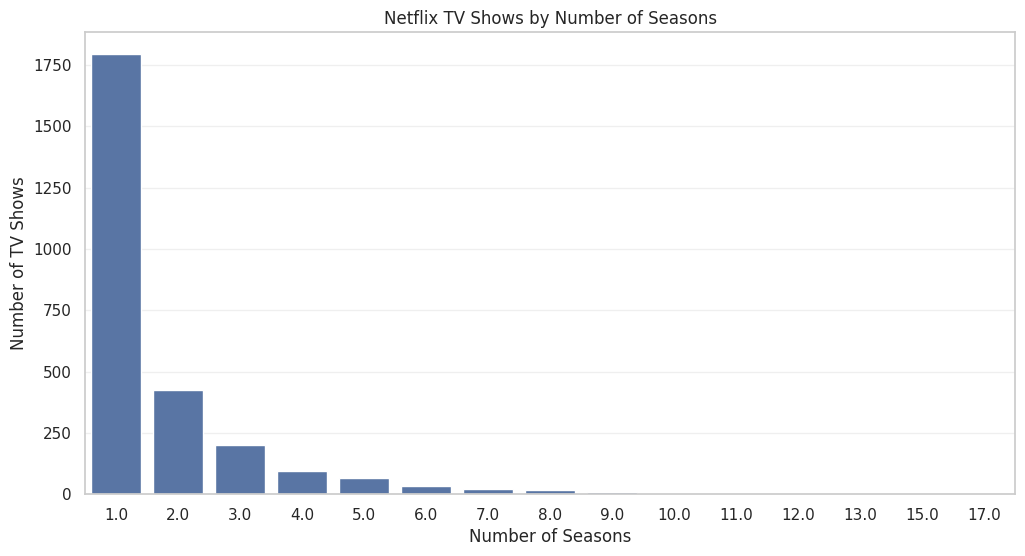

In [91]:
# ==========================================
# TV SHOW SEASONS DISTRIBUTION
# ==========================================

season_counts = tv_seasons['seasons'].value_counts().sort_index()

plt.figure(figsize=(12, 6))

sns.barplot(
    x=season_counts.index,
    y=season_counts.values
)

plt.title('Netflix TV Shows by Number of Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.grid(axis='y', alpha=0.3)

plt.show()

           TOP 10 DIRECTORS
director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Martin Scorsese        12
Youssef Chahine        12
Jay Chapman            12
Name: count, dtype: int64


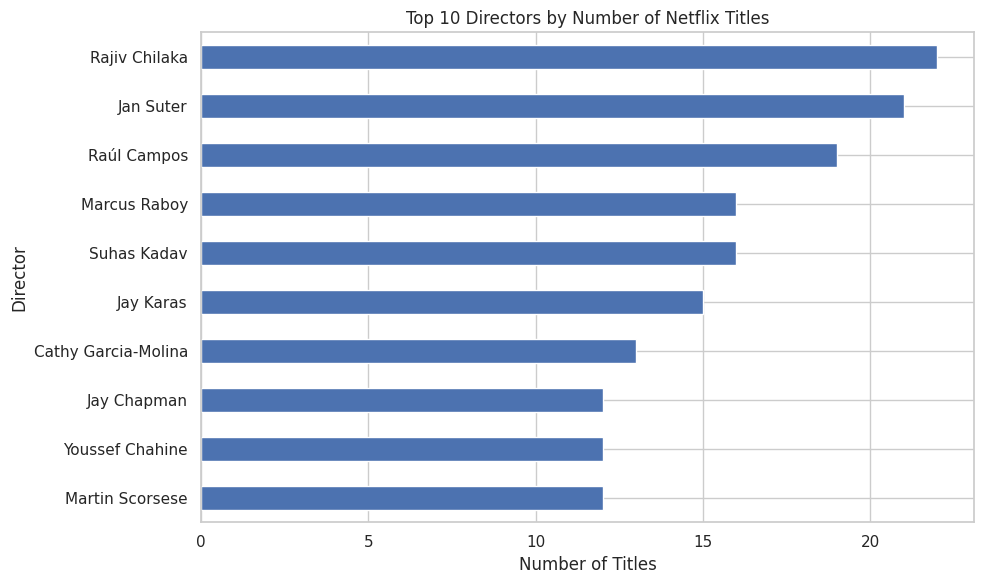

In [92]:
# ==============================================
# TOP 10 DIRECTORS ANALYSIS
# ==============================================

# Remove missing director values
director_data = df['director'].dropna()

# Split multiple directors and count individually
directors = director_data.str.split(', ').explode()

# Count titles directed by each director
top_directors = directors.value_counts().head(10)

print("==============================================")
print("           TOP 10 DIRECTORS")
print("==============================================")
print(top_directors)

# Visualization
plt.figure(figsize=(10, 6))

top_directors.sort_values().plot(kind='barh')

plt.title('Top 10 Directors by Number of Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.tight_layout()
plt.show()

             TOP 10 ACTORS
cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Rupa Bhimani        31
Om Puri             30
Akshay Kumar        30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64


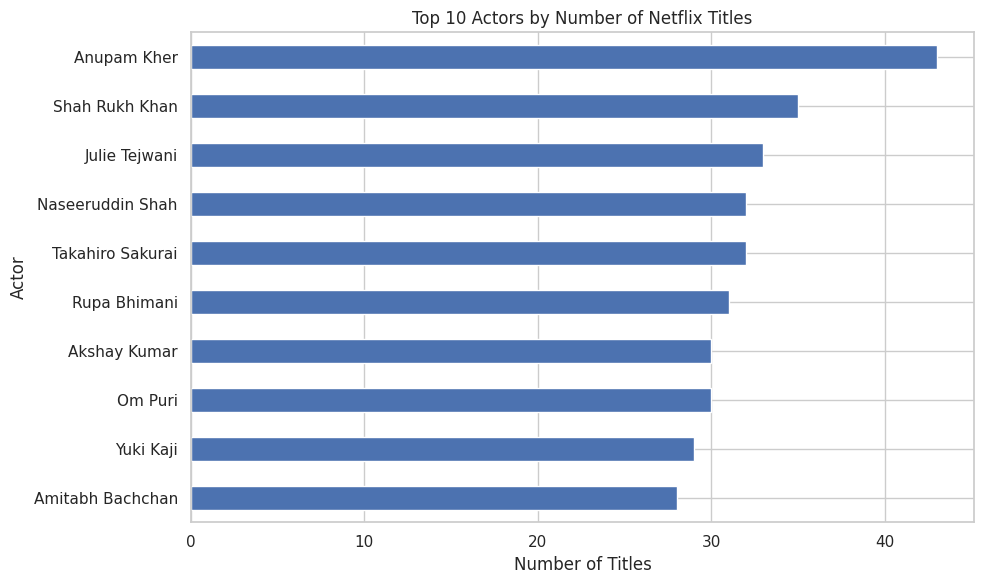

In [93]:
# ==============================================
# TOP 10 ACTORS ANALYSIS
# ==============================================

# Remove missing cast values
cast_data = df['cast'].dropna()

# Split multiple actors and count individually
actors = cast_data.str.split(', ').explode()

# Count appearances
top_actors = actors.value_counts().head(10)

print("==============================================")
print("             TOP 10 ACTORS")
print("==============================================")
print(top_actors)

# Visualization
plt.figure(figsize=(10, 6))

top_actors.sort_values().plot(kind='barh')

plt.title('Top 10 Actors by Number of Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Actor')
plt.tight_layout()
plt.show()

Rating vs Content Type:


type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2


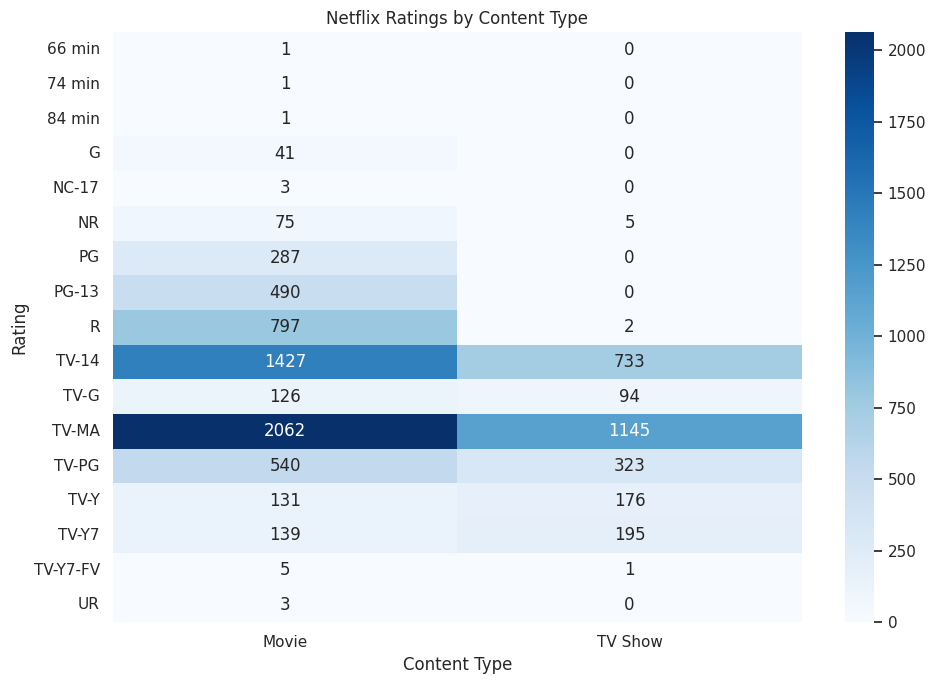

In [94]:
# ==============================================
# ADVANCED VISUALIZATION
# RATING VS CONTENT TYPE HEATMAP
# ==============================================

rating_type = pd.crosstab(
    df['rating'],
    df['type']
)

print("Rating vs Content Type:")
display(rating_type)

# Create heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    rating_type,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Netflix Ratings by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

     TOP 10 COUNTRIES VS CONTENT TYPE


type,Movie,TV Show
country,,
Canada,319,126
France,303,90
Germany,182,44
India,962,84
Japan,119,199
Mexico,111,58
South Korea,61,170
Spain,171,61
United Kingdom,532,272


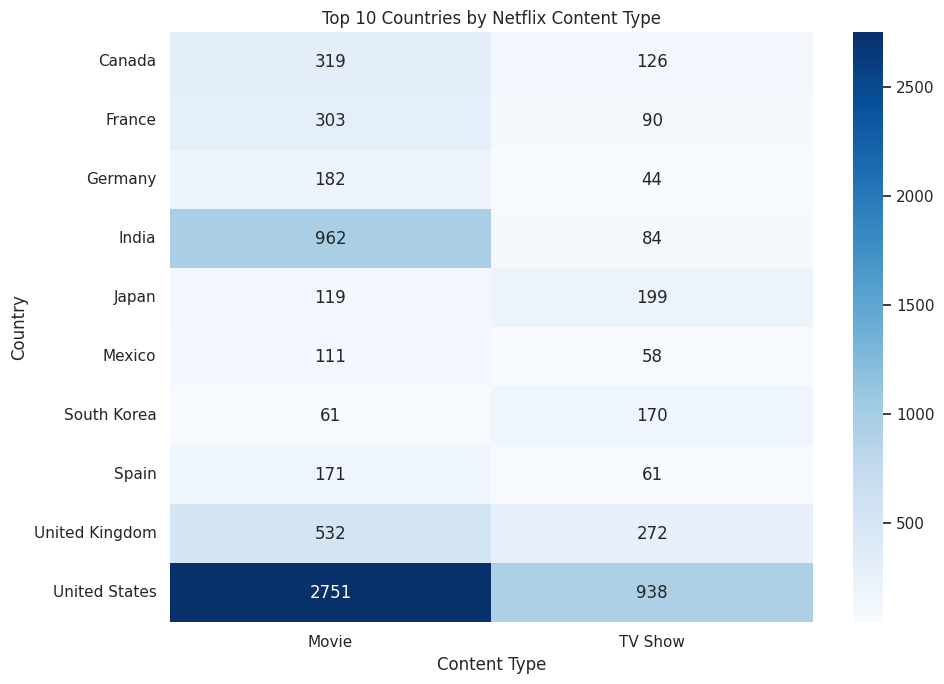

In [95]:
# ==============================================
# COUNTRY VS CONTENT TYPE HEATMAP
# ==============================================

# Remove missing countries
country_data = df[['country', 'type']].dropna().copy()

# Split multiple countries
country_data['country'] = country_data['country'].str.split(', ')

# Create one row for each country
country_data = country_data.explode('country')

# Select top 10 countries overall
top_countries = country_data['country'].value_counts().head(10).index

# Keep only top 10 countries
country_top10 = country_data[
    country_data['country'].isin(top_countries)
]

# Create country vs content type table
country_type = pd.crosstab(
    country_top10['country'],
    country_top10['type']
)

print("==============================================")
print("     TOP 10 COUNTRIES VS CONTENT TYPE")
print("==============================================")
display(country_type)

# Heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    country_type,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Top 10 Countries by Netflix Content Type')
plt.xlabel('Content Type')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

In [99]:
# ================================================================
# 0. IMPORTS (missing hai — isi wajah se error aa raha tha)
# ================================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# ================================================================
# 1. DATA PREPARATION (dashboard ke liye zaroori variables)
# ================================================================

if 'df' not in globals():
    raise NameError("Pehle apni Netflix CSV ko 'df' naam se load karo (upar wali cells run karo).")

netflix = df.copy()
netflix.columns = netflix.columns.str.strip().str.lower()

for col in ['director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in']:
    if col in netflix.columns:
        netflix[col] = netflix[col].fillna('Unknown').astype(str).str.strip()

netflix['type'] = netflix['type'].astype(str).str.strip()

# KPI values
total_titles = len(netflix)
movies = (netflix['type'].str.lower() == 'movie').sum()
tv_shows = (netflix['type'].str.lower() == 'tv show').sum()
movie_pct = (movies / total_titles) * 100
tv_pct = (tv_shows / total_titles) * 100

if 'country' in netflix.columns:
    all_countries = set()
    for value in netflix['country'].replace('Unknown', np.nan).dropna():
        for c in str(value).split(','):
            c = c.strip()
            if c:
                all_countries.add(c)
    country_count = len(all_countries)
else:
    country_count = 0

# Content type counts
type_counts = netflix['type'].value_counts()

# Yearly growth
if 'release_year' in netflix.columns:
    netflix['release_year'] = pd.to_numeric(netflix['release_year'], errors='coerce')
    yearly = netflix.dropna(subset=['release_year']).groupby('release_year').size().reset_index(name='count')
    yearly = yearly[yearly['release_year'] >= 2000]
else:
    yearly = pd.DataFrame(columns=['release_year', 'count'])

# Top countries
if 'country' in netflix.columns:
    country_df = netflix[['country']].dropna().assign(country=lambda x: x['country'].str.split(','))
    country_df = country_df.explode('country')
    country_df['country'] = country_df['country'].astype(str).str.strip()
    country_df = country_df[(country_df['country'] != '') & (country_df['country'].str.lower() != 'unknown')]
    top_countries = country_df['country'].value_counts().head(10).sort_values()
else:
    top_countries = pd.Series(dtype=int)

# Top genres
if 'listed_in' in netflix.columns:
    genre_df = netflix[['listed_in']].dropna().assign(genre=lambda x: x['listed_in'].str.split(','))
    genre_df = genre_df.explode('genre')
    genre_df['genre'] = genre_df['genre'].astype(str).str.strip()
    top_genres = genre_df['genre'].value_counts().head(10).sort_values()
else:
    top_genres = pd.Series(dtype=int)

# Ratings
if 'rating' in netflix.columns:
    rating_counts = netflix['rating'].replace(['Unknown', 'nan'], np.nan).dropna().value_counts()
else:
    rating_counts = pd.Series(dtype=int)

# Country x Type heatmap table
if 'country' in netflix.columns:
    heat_df = netflix[['country', 'type']].dropna().copy()
    heat_df['country'] = heat_df['country'].str.split(',')
    heat_df = heat_df.explode('country')
    heat_df['country'] = heat_df['country'].astype(str).str.strip()
    heat_top = heat_df['country'].value_counts().head(10).index
    heat_df = heat_df[heat_df['country'].isin(heat_top)]
    heat_table = pd.crosstab(heat_df['country'], heat_df['type'])
else:
    heat_table = pd.DataFrame()

# Monthly titles added
if 'date_added' in netflix.columns:
    date_series = pd.to_datetime(netflix['date_added'], errors='coerce')
    monthly_data = date_series.dropna().dt.month.value_counts().sort_index()
else:
    monthly_data = pd.Series(dtype=int)

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_counts = [monthly_data.get(m, 0) for m in range(1, 13)]

# Movie duration
movie_durations = pd.Series(dtype=float)
if 'duration' in netflix.columns:
    movie_duration_raw = netflix.loc[netflix['type'].str.lower() == 'movie', 'duration']
    movie_durations = pd.to_numeric(movie_duration_raw.str.extract(r'(\d+)')[0], errors='coerce').dropna()

if len(movie_durations) > 0:
    avg_movie_duration = movie_durations.mean()
    median_movie_duration = movie_durations.median()
else:
    avg_movie_duration = 0
    median_movie_duration = 0

# TV seasons
tv_seasons = pd.Series(dtype=float)
if 'duration' in netflix.columns:
    tv_duration_raw = netflix.loc[netflix['type'].str.lower() == 'tv show', 'duration']
    tv_seasons = pd.to_numeric(tv_duration_raw.str.extract(r'(\d+)')[0], errors='coerce').dropna()

if len(tv_seasons) > 0:
    avg_seasons = tv_seasons.mean()
    median_seasons = tv_seasons.median()
else:
    avg_seasons = 0
    median_seasons = 0


# ================================================================
# 14. NETFLIX COLORS
# ================================================================

RED = '#E50914'
DARK_RED = '#B20710'
BLACK = '#000000'
CARD = '#111111'
CARD_BORDER = '#333333'
WHITE = '#FFFFFF'
LIGHT_GRAY = '#B3B3B3'
GRID = '#292929'


# ================================================================
# 15. CREATE DASHBOARD  (fixed spacing so charts don't overlap)
# ================================================================

fig = make_subplots(

    rows=6,
    cols=2,

    row_heights=[0.09, 0.20, 0.18, 0.19, 0.21, 0.09],

    specs=[
        [{'type': 'xy'}, {'type': 'xy'}],
        [{'type': 'xy'}, {'type': 'domain'}],
        [{'type': 'xy'}, {'type': 'xy'}],
        [{'type': 'xy'}, {'type': 'heatmap'}],
        [{'type': 'xy', 'colspan': 2}, None],
        [{'type': 'xy'}, {'type': 'xy'}]
    ],

    vertical_spacing=0.06,
    horizontal_spacing=0.07,

    subplot_titles=[
        '', '',
        'CONTENT GROWTH BY RELEASE YEAR', 'CONTENT TYPE DISTRIBUTION',
        'TOP 10 COUNTRIES', 'TOP 10 GENRES',
        'RATING DISTRIBUTION', 'COUNTRY × CONTENT TYPE',
        'TITLES ADDED BY MONTH', '',
        'MOVIE DURATION', 'TV SHOW SEASONS'
    ]
)


# ================================================================
# 16. CHART 1 — RELEASE YEAR  (row 2)
# ================================================================

if not yearly.empty:
    fig.add_trace(
        go.Scatter(
            x=yearly['release_year'], y=yearly['count'],
            mode='lines+markers',
            line=dict(color=RED, width=2),
            marker=dict(color=RED, size=4),
            hovertemplate='Release Year: %{x}<br>Titles: %{y}<extra></extra>'
        ),
        row=2, col=1
    )


# ================================================================
# 17. CHART 2 — CONTENT TYPE DONUT  (row 2)
# ================================================================

fig.add_trace(
    go.Pie(
        labels=type_counts.index,
        values=type_counts.values,
        hole=0.60,
        marker=dict(colors=[RED if str(x).lower() == 'movie' else '#555F63' for x in type_counts.index]),
        textinfo='percent',
        textfont=dict(color=WHITE, size=12),
        hovertemplate='%{label}: %{value}<br>%{percent}<extra></extra>'
    ),
    row=2, col=2
)


# ================================================================
# 18. CHART 3 — TOP COUNTRIES  (row 3)
# ================================================================

if not top_countries.empty:
    fig.add_trace(
        go.Bar(
            x=top_countries.values, y=top_countries.index,
            orientation='h',
            marker=dict(color=RED),
            text=top_countries.values,
            textposition='auto',
            textfont=dict(color=WHITE, size=8),
            cliponaxis=True,
            hovertemplate='%{y}: %{x} titles<extra></extra>'
        ),
        row=3, col=1
    )


# ================================================================
# 19. CHART 4 — TOP GENRES  (row 3)
# ================================================================

if not top_genres.empty:
    fig.add_trace(
        go.Bar(
            x=top_genres.values, y=top_genres.index,
            orientation='h',
            marker=dict(color=RED),
            text=top_genres.values,
            textposition='auto',
            textfont=dict(color=WHITE, size=8),
            cliponaxis=True,
            hovertemplate='%{y}: %{x} titles<extra></extra>'
        ),
        row=3, col=2
    )


# ================================================================
# 20. CHART 5 — RATINGS  (row 4)
# ================================================================

if not rating_counts.empty:
    rating_plot = rating_counts.head(12)

    fig.add_trace(
        go.Bar(
            x=rating_plot.index, y=rating_plot.values,
            marker=dict(color=RED),
            text=rating_plot.values, textposition='outside',
            textfont=dict(color=WHITE, size=8),
            cliponaxis=True,
            hovertemplate='Rating: %{x}<br>Titles: %{y}<extra></extra>'
        ),
        row=4, col=1
    )


# ================================================================
# 21. CHART 6 — HEATMAP  (row 4)
# ================================================================

if not heat_table.empty:
    heat_table = heat_table.reindex(
        columns=[c for c in ['Movie', 'TV Show'] if c in heat_table.columns],
        fill_value=0
    )

    fig.add_trace(
        go.Heatmap(
            z=heat_table.values,
            x=heat_table.columns,
            y=heat_table.index,
            colorscale=[[0, '#111111'], [0.5, '#8B0000'], [1, RED]],
            text=heat_table.values,
            texttemplate='%{text}',
            textfont=dict(color=WHITE, size=9),
            hovertemplate='Country: %{y}<br>Type: %{x}<br>Titles: %{z}<extra></extra>',
            showscale=False
        ),
        row=4, col=2
    )


# ================================================================
# 22. CHART 7 — MONTHLY TITLES (row 5, full width)
# ================================================================

fig.add_trace(
    go.Bar(
        x=month_names, y=monthly_counts,
        marker=dict(color=RED),
        text=monthly_counts, textposition='outside',
        textfont=dict(color=WHITE, size=8),
        cliponaxis=True,
        hovertemplate='%{x}: %{y} titles<extra></extra>'
    ),
    row=5, col=1
)


# ================================================================
# 23. HIDE AXES FOR RESERVED ROWS
# ================================================================

for r in [1, 6]:
    for c in [1, 2]:
        fig.update_xaxes(visible=False, showgrid=False, row=r, col=c)
        fig.update_yaxes(visible=False, showgrid=False, row=r, col=c)


# ================================================================
# 24. MOVIE DURATION PANEL (row 6, left)
# ================================================================

fig.add_annotation(
    x=0.25, y=0.044, xref='paper', yref='paper',
    text=(
        f"<span style='font-size:14px;color:{RED}'>{avg_movie_duration:.2f}</span> min "
        f"<span style='color:{LIGHT_GRAY};font-size:9px'>Average</span><br>"
        f"<b style='font-size:10px'>{median_movie_duration:.0f}</b> min &nbsp; Median"
    ),
    showarrow=False,
    font=dict(color=WHITE, size=10),
    align='center',
    xanchor='center', yanchor='middle'
)


# ================================================================
# 25. TV SHOW SEASONS PANEL (row 6, right)
# ================================================================

fig.add_annotation(
    x=0.75, y=0.044, xref='paper', yref='paper',
    text=(
        f"<span style='font-size:14px;color:{RED}'>{avg_seasons:.2f}</span> seasons "
        f"<span style='color:{LIGHT_GRAY};font-size:9px'>Average</span><br>"
        f"<b style='font-size:10px'>{median_seasons:.0f}</b> &nbsp; Median"
    ),
    showarrow=False,
    font=dict(color=WHITE, size=10),
    align='center',
    xanchor='center', yanchor='middle'
)


# ================================================================
# 26. KPI CARDS — ALL EQUAL SIZE
# ================================================================

kpi_cards = [
    (0.125, f"{total_titles:,}", "TOTAL TITLES", None),
    (0.375, f"{movies:,}",       "MOVIES",       f"{movie_pct:.1f}%"),
    (0.625, f"{tv_shows:,}",     "TV SHOWS",     f"{tv_pct:.1f}%"),
    (0.875, f"{country_count:,}","COUNTRIES",    None)
]

for x, value, label, percentage in kpi_cards:

    pct_text = percentage if percentage else "0.0%"
    pct_color = RED if percentage else "transparent"

    text = (
        f"<span style='font-size:18px;color:white'><b>{value}</b></span><br>"
        f"<span style='font-size:10px;color:white'>{label}</span><br>"
        f"<span style='font-size:9px;color:{pct_color}'>{pct_text}</span>"
    )

    fig.add_annotation(
        x=x, y=0.955, xref='paper', yref='paper',
        text=text,
        showarrow=False,
        align='center',
        xanchor='center', yanchor='middle',
        bgcolor=CARD,
        bordercolor=CARD_BORDER,
        borderwidth=1,
        borderpad=8,
        width=115,
        height=65
    )


# ================================================================
# 27. DASHBOARD TITLE + SUBTITLE
# ================================================================

fig.add_annotation(
    x=0.5, y=1.06, xref='paper', yref='paper',
    text=f"<b><span style='font-size:24px;color:{RED}'>NETFLIX CONTENT ANALYSIS</span></b>",
    showarrow=False,
    xanchor='center',
    font=dict(color=RED)
)

fig.add_annotation(
    x=0.5, y=1.02, xref='paper', yref='paper',
    text="Content Library • Trends • Genres • Global Reach",
    showarrow=False,
    xanchor='center',
    font=dict(color=WHITE, size=11)
)


# ================================================================
# 28. GLOBAL CHART STYLE
# ================================================================

fig.update_layout(
    template='plotly_dark',
    paper_bgcolor=BLACK,
    plot_bgcolor=BLACK,
    font=dict(family='Arial', color=WHITE),
    width=1000,
    height=1300,
    margin=dict(l=60, r=60, t=110, b=40),
    showlegend=False,
    hoverlabel=dict(bgcolor=CARD, font_color=WHITE)
)

fig.update_xaxes(showgrid=True, gridcolor=GRID, zeroline=False, linecolor=GRID, tickfont=dict(color=LIGHT_GRAY, size=8))
fig.update_yaxes(showgrid=True, gridcolor=GRID, zeroline=False, linecolor=GRID, tickfont=dict(color=LIGHT_GRAY, size=8))

for r in [1, 6]:
    for c in [1, 2]:
        fig.update_xaxes(visible=False, showgrid=False, row=r, col=c)
        fig.update_yaxes(visible=False, showgrid=False, row=r, col=c)


# ================================================================
# 29. INDIVIDUAL AXIS SETTINGS
# ================================================================

fig.update_xaxes(title_text='Release Year', title_font=dict(size=9), row=2, col=1)
fig.update_yaxes(title_text='Titles', title_font=dict(size=9), row=2, col=1)

fig.update_xaxes(title_text='Titles', title_font=dict(size=9), row=3, col=1)
fig.update_yaxes(automargin=True, tickfont=dict(size=8), row=3, col=1)

fig.update_xaxes(title_text='Titles', title_font=dict(size=9), row=3, col=2)
fig.update_yaxes(automargin=True, tickfont=dict(size=8), row=3, col=2)

fig.update_xaxes(tickangle=-45, row=4, col=1)
fig.update_yaxes(title_text='Titles', title_font=dict(size=9), row=4, col=1)

fig.update_yaxes(title_text='Titles', title_font=dict(size=9), row=5, col=1)


# ================================================================
# 30. DISPLAY
# ================================================================

fig.show(config={
    'displayModeBar': True,
    'displaylogo': False,
    'responsive': False,
    'scrollZoom': False
})

# 📊 Data Storytelling & Key Insights

## 1. Content Library
Netflix dataset contains 8,807 titles, including 6,131 Movies and 2,676 TV Shows.
Movies represent the larger share of the content library.

## 2. Content Duration
The average movie duration is 99.58 minutes, while TV Shows contain an average of 1.76 seasons.

## 3. Content Ratings
TV-MA is the most common rating, followed by TV-14, showing that a large portion of the Netflix catalog is targeted toward mature and teenage audiences.

## 4. Top Genres
International Movies, Dramas, and Comedies are among the most frequently represented categories in the dataset.

## 5. Global Distribution
The United States has the largest contribution to the Netflix catalog among the countries analyzed, followed by India and the United Kingdom.

## 6. Content Creators
The analysis also identifies the most frequently represented directors and actors in the Netflix catalog.

## 7. Content Addition Trends
The monthly analysis shows variation in the number of titles added throughout the year, indicating that Netflix content additions are not evenly distributed across months.

# 🔎 Key Insights

### 1. Movies Dominate the Content Library
Movies represent approximately 69.6% of the Netflix catalog, while TV Shows
account for approximately 30.4%. This indicates that Netflix's content
library is primarily movie-oriented.

### 2. Strong International Content Presence
The dataset contains content from more than 120 countries, demonstrating
Netflix's global content strategy and broad geographic reach.

### 3. United States is the Largest Content Contributor
The United States contributes the largest number of titles among the
countries analyzed, showing a strong presence of US-produced content.

### 4. International Movies are Highly Represented
International Movies are among the most frequently occurring genres in the
dataset, highlighting Netflix's emphasis on content from different markets.

### 5. Drama is a Major Content Category
Drama is one of the most common genres, indicating strong representation
of drama-based programming in Netflix's catalog.

### 6. TV-MA is the Most Common Rating
TV-MA is the most frequent rating in the cleaned rating data, suggesting
that mature-oriented content represents a significant portion of the
Netflix catalog.

### 7. Movies are Typically Around 100 Minutes Long
The average movie duration is approximately 99.58 minutes, while the median
is 98 minutes. This shows that a typical Netflix movie is around 1.5–2 hours.

### 8. Most TV Shows Have Relatively Few Seasons
TV Shows have an average of approximately 1.76 seasons and a median of
1 season, indicating that many shows in the dataset contain only one or
two seasons.

### 9. Content Addition Varies by Month
The monthly analysis shows that Netflix's title additions are not evenly
distributed throughout the year, with some months receiving noticeably
more additions than others.

### 10. Netflix Has a Diverse Content Portfolio
Overall, the analysis demonstrates a broad content portfolio covering
multiple countries, genres, ratings, movies, and television programming.

# 💡 Business Recommendations

Based on the visualization and analysis, the following recommendations
can be considered:

### 1. Strengthen International Content
Netflix can continue investing in international productions to maintain
its global audience and increase regional engagement.

### 2. Expand High-Performing Genres
Genres such as Drama, International Movies, and Comedies have strong
representation and can be further explored for content acquisition and
production decisions.

### 3. Maintain Regional Content Diversity
The large number of represented countries suggests that regional content
can play an important role in Netflix's global expansion strategy.

### 4. Balance Movies and TV Shows
Although movies dominate the catalog, continued investment in TV Shows
could help maintain a balanced content portfolio.

### 5. Analyze Audience Preferences Further
Future analysis could combine Netflix content data with viewer ratings,
watch time, or engagement data to identify which content categories
perform best with audiences.

### 6. Use Data-Driven Content Planning
Genre, country, rating, and release trends can be monitored regularly
to support future content acquisition and production decisions.

# 🏁 Conclusion

This project transformed the Netflix titles dataset into meaningful
visual insights using Python, Pandas, Matplotlib, and Seaborn.

The analysis examined Netflix's content library, content types, release
trends, countries, genres, ratings, movie durations, TV show seasons,
and monthly content additions.

The final dashboard provides a concise visual summary of the major
patterns in the dataset and demonstrates how data visualization can
support business-oriented analysis and decision-making.

This project fulfills the requirements of **CodeAlpha Task 3:
Data Visualization** by transforming raw data into charts, extracting
insights, and presenting the findings through a structured dashboard
and data story.